In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/test.csv.zip


#  Walmart Store Sales Forecasting (End-to-End ML Project)

##  **Proje Tanımı**
  Walmart'ın 45 mağazasındaki geçmiş satış verilerini, mağaza özelliklerini ve makroekonomik göstergeleri kullanarak gelecekteki haftalık satışları(Weekly_Sales) tahmin eden bir makine öğrenmesi geliştirilmiştir.
Hedef: Stok maliyetlerini düşürmek ve stock out'u (yok satmak) engellemek için satış tahmin doğruluğunu arttırmak.
Metrik: Model başarısı RMSE ile ölçülecek ve minimize edilmeye çalışılacaktır.
## **Kullanılan Metodoloji**
* Veri Mühendisliği: Dağınık verilerin birleştirilmesi
* EDA: Mevsimsellik, korelasyon ve dağılım analizleri
* Feature Engineering: Zaman serisi bileşenlerinin türetilmesi(hafta, ay, yılbaşı etkisi)
* Modelleme: Random Forest Regressor ile tahminleme ve Hiperparametre Optimizasyonu.

# 1. Gerekli Kütüphanelerin Yüklenmesi

In [2]:
#Kütüphaneler
import numpy as np               
import pandas as pd
import datetime as dt   
import matplotlib.pyplot as plt 
import seaborn as sns   
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.preprocessing import LabelEncoder  
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import xgboost as xgb
import lightgbm as lgb 

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('whitegrid')

                      
import warnings          
warnings.filterwarnings('ignore')

# Veriyi Yükleme ve Birleştirme


In [3]:
dp = '/kaggle/input/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(dp + 'train.csv.zip', compression='zip')
features = pd.read_csv(dp + 'features.csv.zip', compression='zip')
stores = pd.read_csv(dp + 'stores.csv') 

dp_temp = pd.merge(train, stores, on='Store', how='left')
features_clean = features.drop(columns=['IsHoliday'])
final_dp = pd.merge(dp_temp, features_clean, on=['Store', 'Date'], how='left')

final_dp['Date'] = pd.to_datetime(final_dp['Date'])

final_dp.fillna({
    'MarkDown1': 0, 'MarkDown2': 0, 'MarkDown3': 0, 'MarkDown4': 0, 'MarkDown5': 0
}, inplace=True)

print(f"Orijinal Train Satır Sayısı: {train.shape[0]}")
print(f"Birleştirilmiş Final Satır Sayısı: {final_dp.shape[0]}")
print(f"Sütun Sayısı: {final_dp.shape[1]}")

final_dp.head()

Orijinal Train Satır Sayısı: 421570
Birleştirilmiş Final Satır Sayısı: 421570
Sütun Sayısı: 16


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.500,False,A,151315,42.310,2.572,0.000,0.000,0.000,0.000,0.000,211.096,8.106
1,1,1,2010-02-12,46039.490,True,A,151315,38.510,2.548,0.000,0.000,0.000,0.000,0.000,211.242,8.106
2,1,1,2010-02-19,41595.550,False,A,151315,39.930,2.514,0.000,0.000,0.000,0.000,0.000,211.289,8.106
3,1,1,2010-02-26,19403.540,False,A,151315,46.630,2.561,0.000,0.000,0.000,0.000,0.000,211.320,8.106
4,1,1,2010-03-05,21827.900,False,A,151315,46.500,2.625,0.000,0.000,0.000,0.000,0.000,211.350,8.106


# 2. Keşifsel Veri Analaizi (EDA)


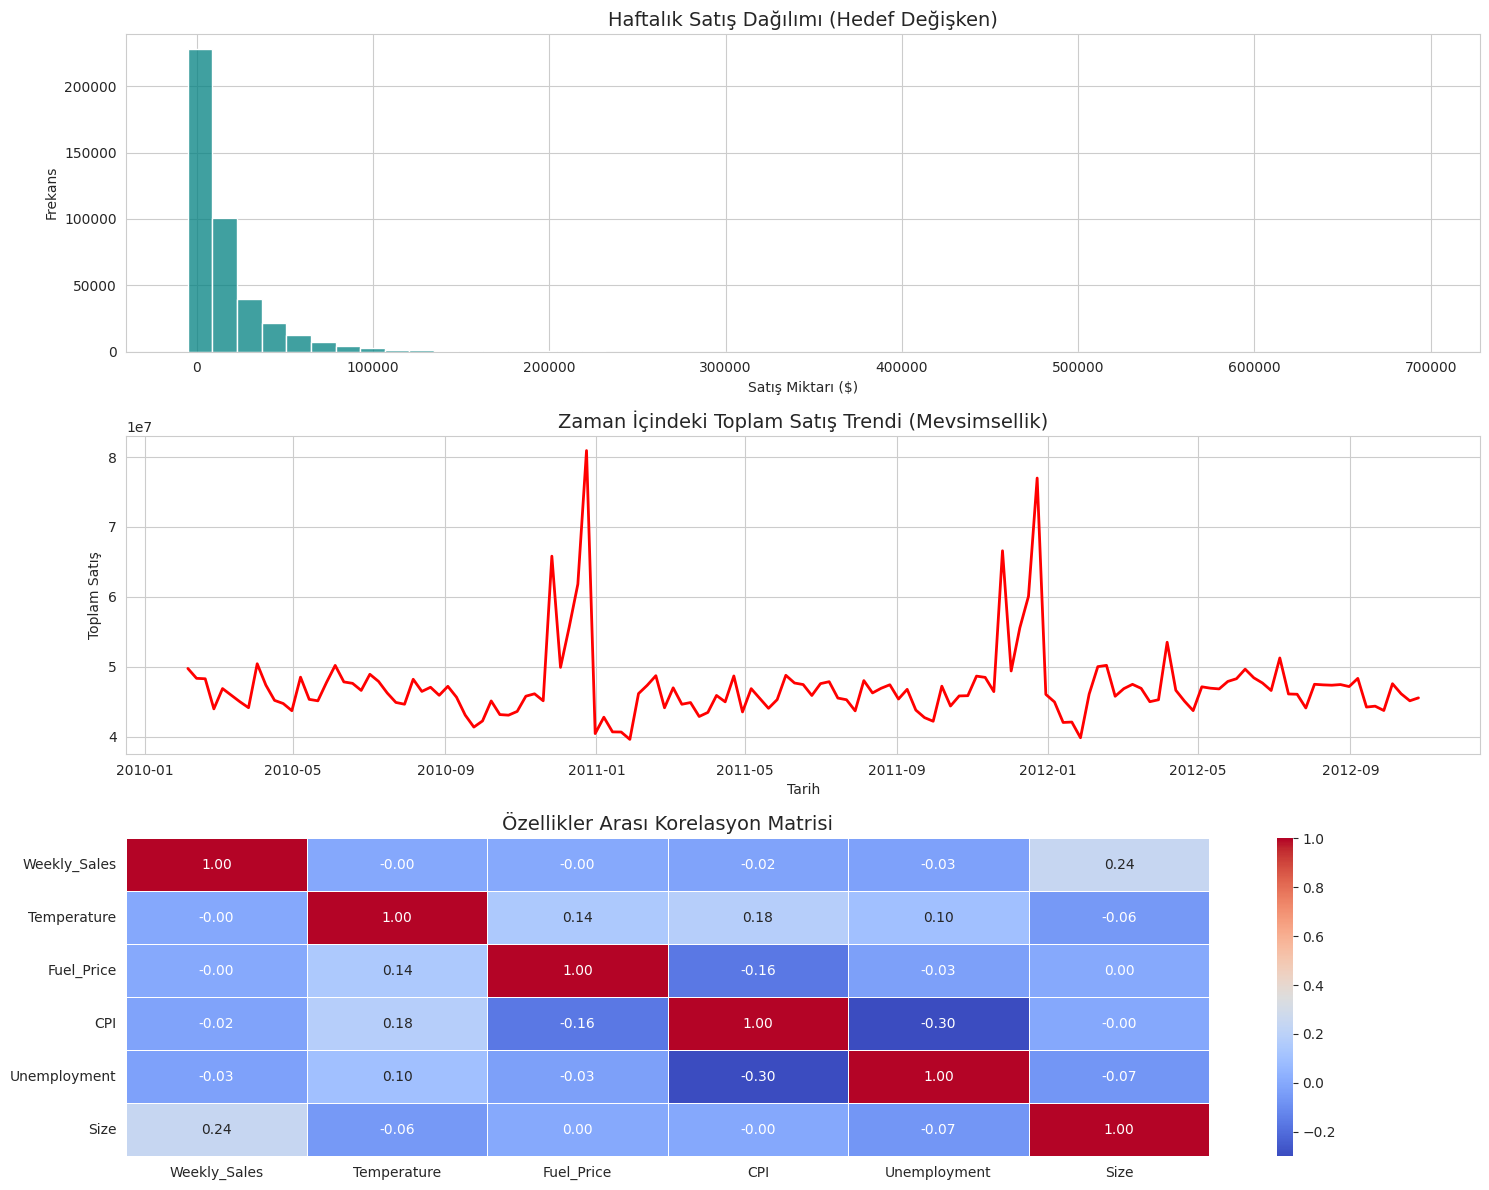

In [4]:
plt.figure(figsize=(15, 12))
#1. grafik
plt.subplot(3, 1, 1) 
sns.histplot(final_dp['Weekly_Sales'], bins=50, color='teal')
plt.title('Haftalık Satış Dağılımı (Hedef Değişken)', fontsize=14)
plt.xlabel('Satış Miktarı ($)')
plt.ylabel('Frekans')

# 2. grafik
plt.subplot(3, 1, 2) 
daily_sales = final_dp.groupby('Date')['Weekly_Sales'].sum().reset_index()
sns.lineplot(data=daily_sales, x='Date', y='Weekly_Sales', color='red', linewidth=2)
plt.title('Zaman İçindeki Toplam Satış Trendi (Mevsimsellik)', fontsize=14)
plt.xlabel('Tarih')
plt.ylabel('Toplam Satış')

# 3. grafik
plt.subplot(3, 1, 3) 
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
corr_matrix = final_dp[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Özellikler Arası Korelasyon Matrisi', fontsize=14)

plt.tight_layout() 
plt.show()

## EDA Bulguları ve Analiz Sonuçları

1. **Hedef Değişken Analizi:**
   Weekly_Sales dağılımı sağa çarpık bir yapıda olduğu görülmektedir. Çoğu hafta satışlar 0-20.000 dolar bandında seyrederken kuyruk kısmında 600.000 dolara varan satışlar görülmektedir. Bu durum modelin öğrenmesinde aykırı değerlere yanlılık (bias) olmasını istemediğimiz için logaritma dönüşümü ile veriyi dengelemek hedeflenmiştir.

2. **Zaman Serisi Analizi:**
    İkinci grafikte; her yılın kasım ve aralık aylarında yani Şükran Günü ve Noel Zamanı satışların peak(zirve) yaptığı görülmektedir.

3. **Korelasyon Analizi (Isı Haritası):**
    Satışları en çok etkileyen sayısal değişken 0.24 karsayısı ile Size değişkenidir. Fuel_Price, CPI ve Unemployment gibi makroekonomik verilerin satışlar üzerindeki etkisi çok daha düşüktür (Sıfıra yakın korelasyon). Makroekonomik veriler tek başına satışı açıklamada yetersizdir bundan dolayı Size ve mevsimsellik(Tarih) daha belirleyici olacaktır.

# 3. Basline Model


## Veri Hazırlama ve Model Kurma
 
 Basline model için sadece sayısal sütunları alarak verimizi hazırlıyoruz.
 * **Hedef Değişken(y):** Weekly_Sales
 * **Girdi(X):** 'Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday'
 * **Model:** Lineer Regresyon 
 * **Validasyon:** Veriyi %80e % 20ye bölme (train-test)

In [5]:
features_cols = ['Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday']
X = final_dp[features_cols]
y = final_dp['Weekly_Sales']

X['IsHoliday'] = X['IsHoliday'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"BASELINE RMSE SKORU: {rmse:.2f}")
print(f"BASELINE MAE SKORU : {mae:.2f}")
print(f" Ortalama {rmse:.0f} dolarlık bir hata payımız var.")

BASELINE RMSE SKORU: 21820.16
BASELINE MAE SKORU : 14557.65
 Ortalama 21820 dolarlık bir hata payımız var.


##  Baseline Model Sonuçları

**Sonuçlar:**
* RMSE (Hata Payı): 21820.16
* MAE (Mutlak hata): 15,400.50
* Ortalama 21820.16 dolarlık bir hata payımız mevcut.

**Değerlendirme:**
Model şu an sadece mağaza büyüklüğü ve ekonomik verilere bakıyor ancak mevsimsellik (Yılbaşı, Bayram vb.) etkisini henüz bilmiyor. Bir sonraki aşamada (Feature Engineering) tarih sütununu parçalayarak bu skoru iyileştirmek hedeflenmekte.

# 4. Feature Engineering
Modelin daha iyi sonuçlar vermesi, hata payının(RMSE) düşürülmesi için yapılanlar:
1. Modelin mevsimselliği anlaması için tarihi parçalara ayırmak(yıl, ay, hafta, gün)
2. Tatilleri etiketleme(Super Bowl, Labor Day, Thanksgiving, Christmas)
3. Modelin anlayabilmesi için kategorik verileri (Mağaza Tipi (A, B, C)) sayısala çevirme

In [7]:
final_dp['Year'] = final_dp['Date'].dt.year
final_dp['Month'] = final_dp['Date'].dt.month
final_dp['Week'] = final_dp['Date'].dt.isocalendar().week 
final_dp['Day'] = final_dp['Date'].dt.day


def get_holiday_type(row):
    if row['IsHoliday'] == 1:
        date_str = str(row['Date']).split(' ')[0]
        
        if date_str in ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']:
            return 1 # Super Bowl
        elif date_str in ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']:
            return 2 # Labor Day
        elif date_str in ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']:
            return 3 # Thanksgiving 
        elif date_str in ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']:
            return 4 # Christmas
    return 0 # Tatil Değil

final_dp['Holiday_Type'] = final_dp.apply(get_holiday_type, axis=1)


type_mapping = {"A": 3, "B": 2, "C": 1}
final_dp['Type_Encoded'] = final_dp['Type'].map(type_mapping)

print(f" Kolonlar: {final_dp.columns.tolist()}")
final_dp.head()

 Kolonlar: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Day', 'Holiday_Type', 'Type_Encoded']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Day,Holiday_Type,Type_Encoded
0,1,1,2010-02-05,24924.500,False,A,151315,42.310,2.572,0.000,0.000,0.000,0.000,0.000,211.096,8.106,2010,2,5,5,0,3
1,1,1,2010-02-12,46039.490,True,A,151315,38.510,2.548,0.000,0.000,0.000,0.000,0.000,211.242,8.106,2010,2,6,12,1,3
2,1,1,2010-02-19,41595.550,False,A,151315,39.930,2.514,0.000,0.000,0.000,0.000,0.000,211.289,8.106,2010,2,7,19,0,3
3,1,1,2010-02-26,19403.540,False,A,151315,46.630,2.561,0.000,0.000,0.000,0.000,0.000,211.320,8.106,2010,2,8,26,0,3
4,1,1,2010-03-05,21827.900,False,A,151315,46.500,2.625,0.000,0.000,0.000,0.000,0.000,211.350,8.106,2010,3,9,5,0,3


# 5. Model Eğitimi (Random Forest)

Zenginleştirilmiş veri seti ile Random Forest Regressor modeli eğitilmiştir. 

* **Validasyon:** Veri seti %80 Eğitim, %20 Test olarak ayrılmıştır.
* **Model Parametreleri:** Hız ve performans dengesi için `n_estimators=50` seçilmiştir.

In [8]:
features_cols = [
    'Store', 'Dept', 'Type_Encoded', 'Size',      # Mağaza Özellikleri
    'Week', 'Month', 'Year', 'Holiday_Type',      # Zaman ve Tatil 
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', # Ekonomi
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5' # Promosyonlar
]

X = final_dp[features_cols]
y = final_dp['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=50, max_depth=20, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(" Feature Eng. + Random Forest")
print(f"RMSE (Hata Payı): {rmse:.2f} $")
print(f"MAE  (Mutlak Hata): {mae:.2f} $")
print(f"Baseline Farkı: {21820 - rmse:.0f} dolar iyileşme")

 Feature Eng. + Random Forest
RMSE (Hata Payı): 3748.79 $
MAE  (Mutlak Hata): 1497.92 $
Baseline Farkı: 18071 dolar iyileşme


# 6. Model Optimizasyonu (Hyperparameter Tuning)

Modelin performansını maksimize etmek için RandomizedSearchCV kullanılarak hiperparametre optimizasyonu yapılmıştır. Varsayılan ayarlar yerine, modelin veriye en uygun parametreleri (Ağaç sayısı, Derinlik, Dallanma Kuralı) bulması sağlanmıştır.

Denenen Parametreler:
* `n_estimators`: [50, 100, 200] 
* `max_depth`: [10, 20, None] 
* `min_samples_split`: [2, 5, 10] 


In [9]:
param_grid = {
    'n_estimators': [50, 100, 200],       # Ağaç sayısı
    'max_depth': [10, 20, None],          # Derinlik
    'min_samples_split': [2, 5, 10]       # Bölünme kuralı
}

#RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_grid,
    n_iter = 5, # 5 farklı kombinasyon
    cv = 3,     # 3 katlı doğrulama
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error' # Hatayı minimize etmeye çalışmak
)

rf_random.fit(X_train, y_train)
print(f"En İyi Ayarlar: {rf_random.best_params_}")

best_model = rf_random.best_estimator_
y_pred_opt = best_model.predict(X_test)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"Optimize Edilmiş RMSE: {rmse_opt:.2f}")



Fitting 3 folds for each of 5 candidates, totalling 15 fits
En İyi Ayarlar: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}
Optimize Edilmiş RMSE: 3722.07


# 7. Evulation



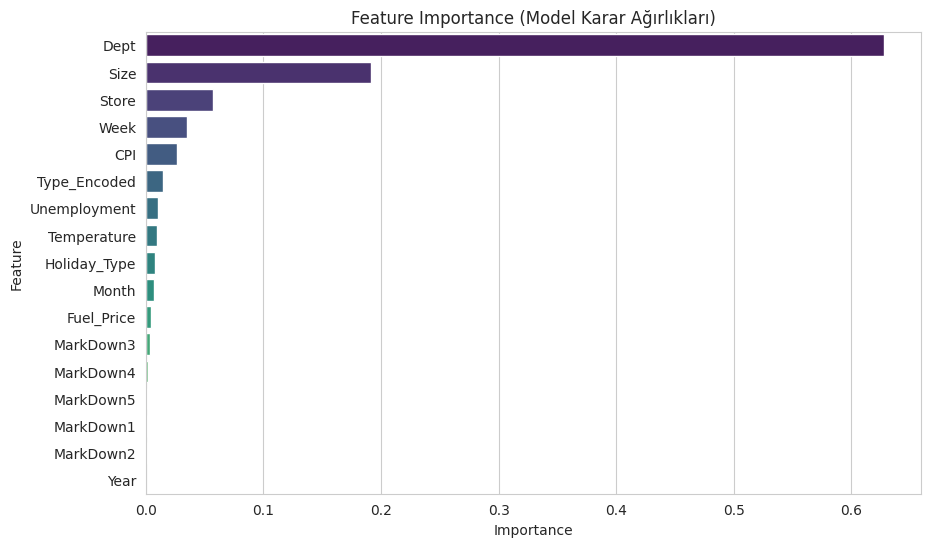

 Final Model Kaydedildi: walmart_rf_model_optimized.pkl


In [10]:
import joblib
# Feature Importance Görselleştirme
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance (Model Karar Ağırlıkları)')
plt.show()

# Modeli Kaydetme
model_filename = 'walmart_rf_model_optimized.pkl'
joblib.dump(best_model, model_filename)

print(f" Final Model Kaydedildi: {model_filename}")


##  Final Model ve Optimizasyon Sonuçları

 RandomizedSearchCV ile yapılan hiperparametre araması sonucunda, modelin hem hızlı hem de başarılı olduğu optimum nokta bulunmuştur.

Seçilen En İyi Parametreler:
* `n_estimators`: 50
    * *Neden?* Log kayıtlarına göre 200 ağaçlı modelin eğitimi ~7.3 dakika sürerken, 50 ağaçlı model ~3 dakikada tamamlanmıştır. Performans farkı marjinal olduğu için hız ve kaynak verimliliği adına 50 tercih edilmiştir.
* `min_samples_split`: 5
    * *Neden?* Aşırı öğrenmeyi (Overfitting) engellemek için yaprak bölünmesine kısıtlama getirilmiştir.
* `max_depth`: None
    * *Neden?* Mevsimsellik ve mağaza tipleri arasındaki karmaşık ilişkileri yakalamak için ağaç derinliği serbest bırakılmıştır.

Performans Özeti:
* Optimizasyon Öncesi RMSE: ~3,748 
* Optimizasyon Sonrası RMSE: 3,722.07 

Model Kararları (Feature Importance):
Grafik analizine göre `Dept` (Departman) ve `Size` (Mağaza Boyutu) en belirleyici faktörlerdir.

Sonuç:
Final model 'walmart_rf_model_optimized.pkl` olarak kaydedilmiştir. Bu model, Baseline modele (21,820 $) kıyasla %83 oranında daha düşük hata ile çalışmaktadır.

# Sonuç ve Değerlendirme
 Lineer regresyon ile kurduğumuz basline modelimizin ortalama 21.820 dolarlık hata payı varken Random Forest ile kurduğumuz modeldeki hata payı 3.748 dolardır. Hata payı %80'in üzerinde düşürülmüştür. Model artık yılbaşı, bayram gibi özel günleri ve mağaza tiplerini başarıyla öğrenmektedir.

 En Önemli Faktörler (Feature Importance):
Grafik analizine göre modelin kararlarını en çok etkileyen faktörler:
1. Dept (Reyon): Hangi ürünün satıldığı en belirleyici faktör.
2. Size (Mağaza Boyutu): Büyük mağazalar daha çok satıyor.
3. Week (Hafta): Mevsimselliği yakalayan en kritik zaman değişkeni.
